In [17]:
import pandas as pd
import re

# Function to parse class_acc string into a dict
def parse_class_acc(dict_str):
    matches = re.findall(r"'([^']+)': np\.float64\(([^)]+)\)", dict_str)
    return {key: float(value) for key, value in matches}

# List of your CSV files
csv_files = ["output_4.csv", "output_5.csv", "output_6.csv"]

# To store the max per class for each CSV
maxes_list = []

for file in csv_files:
    df = pd.read_csv(file)
    # Expand last column
    class_acc_df = pd.DataFrame(df['class_acc'].apply(parse_class_acc).tolist())
    # Take max for each class
    maxes = class_acc_df.max()
    maxes_list.append(maxes)

# Combine maxes from all CSVs into one DataFrame
max_df = pd.DataFrame(maxes_list, index=[f"model_{i+1}" for i in range(len(csv_files))])
max_df = max_df.reset_index().rename(columns={"index": "model"})
long_df = max_df.melt(id_vars="model", var_name="class", value_name="value")

print(max_df)
# Optionally save to CSV
long_df.to_csv("long_maxes.csv", index=False)
max_df.to_csv("class_maxes.csv", index=False)


     model      five      four       one     reset      rock     synth  \
0  model_1  0.747089  0.420148  0.628568  0.620376  0.409985  0.810868   
1  model_2  0.886301  0.000000  0.993668  0.000000  0.000000  0.405257   
2  model_3  0.615922  0.457688  0.620783  0.435003  0.282784  0.846386   

      three  thumbs_up       two  
0  0.328559   0.612249  0.707351  
1  0.000000   0.000213  0.876134  
2  0.402995   0.383910  0.624773  


<Figure size 1000x500 with 0 Axes>

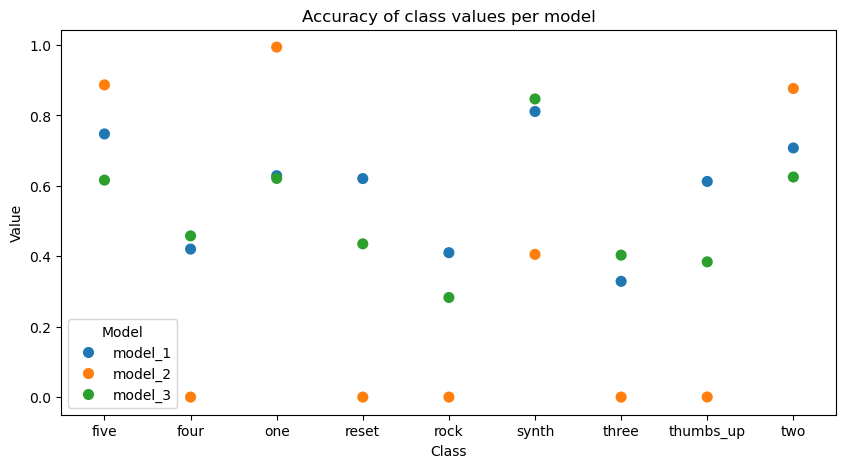

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df = max_df

df_t = df.set_index("model").T.reset_index()
df_t = df_t.rename(columns={"index": "class"})
df = df_t.melt(id_vars="class", var_name="model", value_name="value")

long_df = df_t.melt(id_vars="class", var_name="model", value_name="value")
plt.figure(figsize=(10,5))

sns.stripplot(
    data=long_df, 
    x="class", 
    y="value", 
    hue="model", 
    size=8,    # size of dots
    jitter=False # spreads overlapping dots
)

plt.title("Accuracy of class values per model")
plt.xlabel("Class")
plt.ylabel("Value")
plt.legend(title="Model")
plt.show()
